# Case 3: 2D CO2 Displacement of Brine — an ICFERST-informed PINN

## 1. Learning objectives and scope

This university tutorial connects a verified two-phase ICFERST simulation to a
physics-informed neural network (PINN). You will learn to separate sparse observations
from unlabeled collocation points, construct two phase-balance residuals, validate at
complete unseen times, and interpret front and inventory errors.

The goal is a transparent teaching benchmark. It is **not a calibrated storage-site model**.

## 2. Physical problem, assumptions, and fixed parameters

Supercritical CO2 enters the left edge of a homogeneous $300\,\mathrm{m}\times150\,\mathrm{m}$
rectangle and displaces brine toward a fixed-pressure outlet. The simulation lasts 300 days.
Porosity is 0.20 and isotropic permeability is $10^{-12}\,\mathrm{m^2}$. Densities are
1000 and 700 kg/m³; viscosities are $10^{-3}$ and $7\times10^{-5}$ Pa s. Residual brine
saturation is 0.20, and both Corey exponents are 2.

The inlet profile is
$$q(y)=10^{-6}\left[1+0.5\cos\left(2\pi(y/150-0.5)\right)\right]\ \mathrm{m/s}.$$

We deliberately neglect gravity, capillary pressure, dissolution, compressibility, and
heterogeneity so that students can focus on two-phase conservation and PINN validation.

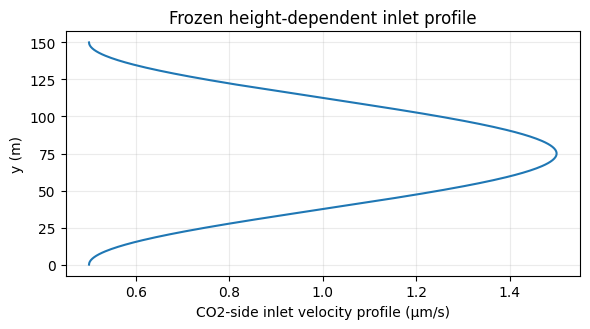

In [1]:
import base64, hashlib, io, math, os, random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
LX, LY, FINAL_TIME = 300.0, 150.0, 300.0*86400.0
PHI, K = 0.20, 1.0e-12
MU_BRINE, MU_CO2 = 1.0e-3, 7.0e-5
SWR, S_CO2_MAX = 0.20, 0.80
Q0, P_OUT, P_SCALE = 1.0e-6, 1.0e7, 2.0e5
INITIAL_GATE_TIME = 86400.0

def inlet_flux(y_m):
    return Q0*(1.0 + 0.5*np.cos(2.0*np.pi*(y_m/LY - 0.5)))

y_line = np.linspace(0.0, LY, 301)
plt.figure(figsize=(6, 3.4))
plt.plot(inlet_flux(y_line)*1e6, y_line)
plt.xlabel("CO2-side inlet velocity profile (µm/s)"); plt.ylabel("y (m)")
plt.title("Frozen height-dependent inlet profile"); plt.grid(alpha=0.25)
plt.tight_layout(); plt.show()

## 3. ICFERST reference simulation and provenance

This classroom notebook does **not** run ICFERST. It directly consumes the prepared,
checksum-verified NPZ reference dataset so class time can focus on the PINN. The original
mesh, MPML input, metadata, checksum manifest, and Host B validation report are supplied as
separate reproducibility attachments.

ICFERST solved the fixed two-phase problem on a 61×31-vertex triangular mesh with a one-day
time step. The accepted Host B run reached 25,920,000 s with return code zero. Sixteen unique
snapshots passed finite-value, saturation-sum, monotone-inventory, and checksum checks; the
injected-versus-stored/outflow mismatch was 0.536%.

ICFERST applies the inlet phase fractions weakly. Consequently, exported discontinuous-
Galerkin values located at $x=0$ are cell-field values, not the exact mathematical boundary
trace $S_{CO2}=0.8$. The PINN therefore learns the exported field while the prescribed phase
flux terms carry the inlet physics; these two quantities should not be conflated.

The compact NPZ contains ICFERST reference fields and immutable split indices. It is embedded
in this notebook, decoded locally, and checked against its SHA-256 before loading. No Drive
permission, external download, or upload widget is required. ICFERST values are reference
simulation results, not analytical truth.

In [2]:
#@title Embedded checksum-verified ICFERST reference data (no download required)
DATA_SHA256 = '503c2bd1c2672e2cdfa3d41442c312582c4e7eb0a2c3c9e69ad86e0f8de24940'
DATA_NAME = 'co2_brine_icferst_teaching.npz'
EMBEDDED_DATA_B64 = (
"..."
)

def sha256_bytes(payload):
    return hashlib.sha256(payload).hexdigest()

def obtain_dataset_bytes():
    payload = base64.b64decode(EMBEDDED_DATA_B64, validate=True)
    observed = sha256_bytes(payload)
    if observed != DATA_SHA256:
        raise ValueError(f"Dataset SHA-256 mismatch: {observed}")
    print(f"Embedded dataset verified: {observed}")
    return payload

DATA = {}
with np.load(io.BytesIO(obtain_dataset_bytes())) as archive:
    DATA.update({name: archive[name] for name in archive.files})
print({name: value.shape for name, value in DATA.items()})

Embedded dataset verified: 503c2bd1c2672e2cdfa3d41442c312582c4e7eb0a2c3c9e69ad86e0f8de24940
{'x_m': (172800,), 'y_m': (172800,), 'time_s': (172800,), 'pressure_pa': (172800,), 's_co2': (172800,), 's_brine': (172800,), 'snapshot_id': (172800,), 'is_boundary': (172800,), 'observation_rows': (12320,), 'heldout_rows': (43200,), 'heldout_snapshot_ids': (4,), 'collocation_pool_rows': (129600,)}


## 4. Load and visualize the simulation data

The plots below show selected ICFERST saturation snapshots. The curved front is caused by the
nonuniform inlet profile. Repeated discontinuous-Galerkin point coordinates are averaged only
for visualization; all stored rows remain available for training and evaluation.

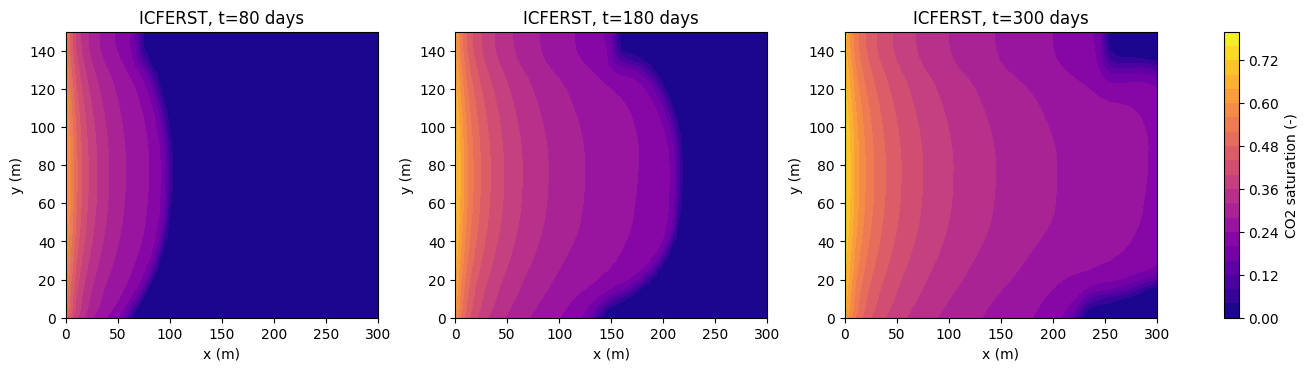

In [3]:
def unique_xy_field(rows, values):
    xy = np.column_stack((DATA["x_m"][rows], DATA["y_m"][rows]))
    unique, inverse = np.unique(xy, axis=0, return_inverse=True)
    averaged = np.bincount(inverse, weights=values)/np.bincount(inverse)
    return unique[:, 0], unique[:, 1], averaged

figure, axes = plt.subplots(1, 3, figsize=(13, 3.6), constrained_layout=True)
snapshot_ids = np.unique(DATA["snapshot_id"])
for axis, sid in zip(axes, snapshot_ids[[4, 9, 15]]):
    rows = np.flatnonzero(DATA["snapshot_id"] == sid)
    x, y, s = unique_xy_field(rows, DATA["s_co2"][rows])
    artist = axis.tricontourf(x, y, s, levels=np.linspace(0, 0.8, 21), cmap="plasma")
    axis.set(xlabel="x (m)", ylabel="y (m)",
             title=f"ICFERST, t={DATA['time_s'][rows[0]]/86400:.0f} days")
figure.colorbar(artist, ax=axes, label="CO2 saturation (-)")
plt.show()

## 5. Governing equations and nondimensionalization

With $S_b=1-S_c$, common pressure, and no gravity or capillarity,
$$\phi\partial_t S_\alpha+\nabla\cdot\mathbf v_\alpha=0,\qquad
\mathbf v_\alpha=-\frac{Kk_{r\alpha}}{\mu_\alpha}\nabla p.$$
Effective CO2 saturation is $S_c/0.8$, so $k_{rc}=(S_c/0.8)^2$ and
$k_{rb}=(1-S_c/0.8)^2$. Coordinates are mapped to $[-1,1]^3$ inside the network.
Residuals are multiplied by $T/\phi$ so their numerical scale is suitable for optimization.

In [4]:
def relative_permeability(s_co2):
    effective = torch.clamp(s_co2/S_CO2_MAX, 0.0, 1.0)
    return (1.0-effective).square(), effective.square()

def gradient(output, inputs):
    return torch.autograd.grad(output, inputs, torch.ones_like(output),
                               create_graph=True, retain_graph=True)[0]

## 6. Leakage-free train and validation split

Four complete times are held out. At all other times, no more than 10% of eligible interior
rows carry pressure and saturation labels. PDE collocation rows carry coordinates only—never
ICFERST targets. This prevents a common form of validation leakage.

Sparse labeled rows: 12,320
Held-out rows: 43,200; held-out snapshots: [ 1  5 10 15]


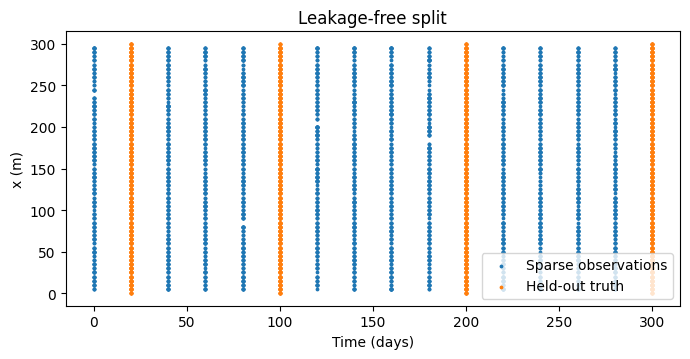

In [5]:
heldout = DATA["heldout_rows"]
observed = DATA["observation_rows"]
assert not np.intersect1d(heldout, observed).size
print(f"Sparse labeled rows: {observed.size:,}")
print(f"Held-out rows: {heldout.size:,}; held-out snapshots: {DATA['heldout_snapshot_ids']}")
plt.figure(figsize=(7, 3.7))
show_obs = observed[::max(1, observed.size//2500)]
show_test = heldout[::max(1, heldout.size//2500)]
plt.scatter(DATA["time_s"][show_obs]/86400, DATA["x_m"][show_obs], s=3, label="Sparse observations")
plt.scatter(DATA["time_s"][show_test]/86400, DATA["x_m"][show_test], s=3, label="Held-out truth")
plt.xlabel("Time (days)"); plt.ylabel("x (m)"); plt.legend(); plt.title("Leakage-free split")
plt.tight_layout(); plt.show()

## 7. Two-branch PINN architecture

Separate tanh MLPs represent pressure and saturation. Pressure is scaled around the 10 MPa
outlet value. A hard one-day gate enforces the initially uniform pressure and zero CO2
saturation exactly. The saturation branch receives only $q(y)/q_0$ and the
Buckley--Leverett similarity coordinate $x/[q(y)t]$, directly enforcing the self-similar
displacement structure supported by the training snapshots. This resolves a narrow early
plume without using held-out labels. The sigmoid output enforces $0\le S_{CO2}\le0.8$.

In [6]:
def make_mlp(width, depth, input_features=3):
    layers=[]; inputs=input_features
    for _ in range(depth):
        layers += [nn.Linear(inputs, width), nn.Tanh()]; inputs=width
    layers += [nn.Linear(inputs, 1)]
    network=nn.Sequential(*layers)
    for layer in network:
        if isinstance(layer, nn.Linear):
            nn.init.xavier_normal_(layer.weight); nn.init.zeros_(layer.bias)
    return network

def saturation_features(xyt):
    xf=xyt[:,0:1]/LX; yf=xyt[:,1:2]/LY; tf=xyt[:,2:3]/FINAL_TIME
    flux_ratio=1.0+0.5*torch.cos(2.0*math.pi*(yf-0.5))
    positive=tf>0.0
    travel_scale=torch.where(positive,flux_ratio*tf,torch.ones_like(tf))
    similarity=torch.where(positive,xf/travel_scale,torch.zeros_like(xf))
    return torch.cat((flux_ratio,similarity),dim=1)

class TwoBranchPINN(nn.Module):
    def __init__(self, width=64, depth=4):
        super().__init__()
        self.pressure_branch=make_mlp(width, depth)
        self.saturation_branch=make_mlp(width, depth, input_features=2)
        self.register_buffer("lower", torch.tensor([0., 0., 0.]))
        self.register_buffer("upper", torch.tensor([LX, LY, FINAL_TIME]))
    def forward(self, xyt):
        z=2.0*(xyt-self.lower)/(self.upper-self.lower)-1.0
        gate=-torch.expm1(-xyt[:,2:3]/INITIAL_GATE_TIME)
        pressure=P_OUT+gate*P_SCALE*self.pressure_branch(z)
        saturation=gate*S_CO2_MAX*torch.sigmoid(self.saturation_branch(saturation_features(xyt)))
        return pressure, saturation

## 8. Physics, data, initial, and boundary losses

The objective includes both phase mass balances, sparse pressure and saturation observations,
the initially brine-filled state, inlet saturation/flux, outlet pressure, top/bottom no-flow,
and a global injected-inventory constraint. Only the two data terms use ICFERST point labels.

In [7]:
def phase_fields(model, xyt):
    xyt=xyt.requires_grad_(True); pressure, saturation=model(xyt)
    grad_p=gradient(pressure, xyt); krb, krc=relative_permeability(saturation)
    vb=-K*krb/MU_BRINE*grad_p[:, :2]; vc=-K*krc/MU_CO2*grad_p[:, :2]
    return xyt,pressure,saturation,vb,vc

def phase_residuals(model, xyt):
    xyt,pressure,saturation,vb,vc=phase_fields(model,xyt)
    dsdt=gradient(saturation, xyt)[:, 2:3]
    divergence=[]
    for velocity in (vb, vc):
        value=0.0
        for component in range(2):
            value=value+gradient(velocity[:, component:component+1], xyt)[:, component:component+1]
        divergence.append(value)
    scale=FINAL_TIME/PHI
    return scale*(-PHI*dsdt+divergence[0]), scale*(PHI*dsdt+divergence[1])

def xyt(rows):
    return np.column_stack((DATA["x_m"][rows], DATA["y_m"][rows], DATA["time_s"][rows])).astype("float32")

def sample_batch(n_pde, n_obs, n_constraint, rng):
    pde_rows=rng.choice(DATA["collocation_pool_rows"], n_pde, replace=True)
    obs_rows=rng.choice(DATA["observation_rows"], n_obs, replace=True)
    xy=rng.random((n_constraint,2))*[LX,LY]
    initial=np.c_[xy, np.zeros(n_constraint)].astype("float32")
    y=rng.random(n_constraint)*LY; t=rng.random(n_constraint)*FINAL_TIME
    inlet=np.c_[np.zeros(n_constraint),y,t].astype("float32")
    outlet=np.c_[np.full(n_constraint,LX),y,t].astype("float32")
    half=n_constraint//2
    walls=np.c_[rng.random(n_constraint)*LX,
                np.r_[np.zeros(half),np.full(n_constraint-half,LY)],
                rng.random(n_constraint)*FINAL_TIME].astype("float32")
    geometry_rows=np.flatnonzero(DATA["snapshot_id"]==0)
    inventory_time=20.0*86400.0
    inventory=np.c_[DATA["x_m"][geometry_rows],DATA["y_m"][geometry_rows],
                    np.full(geometry_rows.size,inventory_time)].astype("float32")
    inventory_target=np.array([[S_CO2_MAX*Q0*inventory_time/(PHI*LX)]],dtype="float32")
    return {
        "pde": {"xyt": xyt(pde_rows)},
        "obs": {"xyt": xyt(obs_rows), "pressure": DATA["pressure_pa"][obs_rows,None].astype("float32"),
                 "s_co2": DATA["s_co2"][obs_rows,None].astype("float32")},
        "initial": initial,
        "inlet": {"xyt":inlet,"flux":inlet_flux(y).astype("float32")[:,None]},
        "outlet": outlet, "walls":walls,
        "inventory":{"xyt":inventory,
                     "time_group":np.zeros((geometry_rows.size,1),dtype="int64"),
                     "mean_target":inventory_target},
    }

def time_balanced_saturation_mse(prediction, truth, time_s):
    terms=[]
    for value in torch.unique(time_s.detach()):
        selected=time_s[:,0]==value
        error_energy=(prediction[selected]-truth[selected]).square().mean()
        truth_energy=truth[selected].square().mean()
        terms.append(0.1**2*error_energy/(truth_energy+0.01**2))
    return torch.stack(terms).mean()

def compute_losses(model, batch, device, weights=None):
    tensor=lambda value: torch.as_tensor(value, dtype=torch.float32, device=device)
    rb,rc=phase_residuals(model,tensor(batch["pde"]["xyt"]))
    obs_xyt=tensor(batch["obs"]["xyt"]); obs_s=tensor(batch["obs"]["s_co2"])
    po,so=model(obs_xyt); _,si=model(tensor(batch["initial"]))
    _,pin,sin,vbin,vcin=phase_fields(model,tensor(batch["inlet"]["xyt"]))
    pout,_=model(tensor(batch["outlet"])); _,_,_,vbwall,vcwall=phase_fields(model,tensor(batch["walls"]))
    _,sinventory=model(tensor(batch["inventory"]["xyt"]))
    inventory_terms=[]
    groups=tensor(batch["inventory"]["time_group"])
    targets=tensor(batch["inventory"]["mean_target"])
    for group in range(targets.shape[0]):
        selected=groups[:,0]==float(group)
        inventory_terms.append((sinventory[selected].mean()-targets[group,0]).square())
    losses={
        "pde_brine": rb.square().mean(), "pde_co2": rc.square().mean(),
        "data_pressure": ((po-tensor(batch["obs"]["pressure"]))/P_SCALE).square().mean(),
        "data_saturation": time_balanced_saturation_mse(so,obs_s,obs_xyt[:,2:3]),
        "initial": si.square().mean(),
        "inlet": (sin-S_CO2_MAX).square().mean()
                 +((vcin[:,0:1]-S_CO2_MAX*tensor(batch["inlet"]["flux"]))/Q0).square().mean()
                 +(vbin[:,0:1]/Q0).square().mean(),
        "outlet": ((pout-P_OUT)/P_SCALE).square().mean(),
        "no_flow": (vbwall[:,1:2]/Q0).square().mean()+(vcwall[:,1:2]/Q0).square().mean(),
        "inventory": torch.stack(inventory_terms).mean(),
    }
    active={"pde_brine":1,"pde_co2":1,"data_pressure":1,"data_saturation":10,
            "initial":5,"inlet":2,"outlet":1,"no_flow":1,"inventory":1}
    if weights: active.update(weights)
    losses["total"]=sum(active[name]*value for name,value in losses.items())
    return losses

## 9. GPU-first training with CPU fallback

A real CUDA tensor operation is required before selecting a GPU. Any initialization failure
is reported and execution immediately continues on CPU. `FAST_MODE=True` is the recommended
classroom setting; the accurate setting uses more samples and iterations. Training has two
explicit stages: the self-similar saturation branch is first fitted only to sparse rows from
the earliest nonzero training snapshot (40 days), then frozen while pressure and the two
phase-balance residuals are optimized. Held-out rows never enter either stage.

Using GPU: Tesla T4
1 3036.0146484375
500 3816.6953125
1000 4192.28271484375
1500 3174.630126953125
2000 4167.76416015625
2500 4098.931640625
3000 3010.6328125


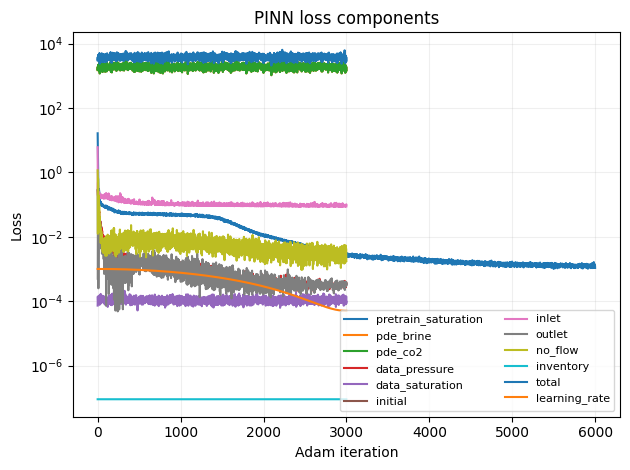

In [8]:
def select_device(probe=None):
    if torch.cuda.is_available():
        try:
            device=torch.device("cuda")
            if probe is None:
                value=torch.ones(1,device=device); assert (value*value).item()==1.0
            else: probe(device)
            print(f"Using GPU: {torch.cuda.get_device_name(0)}"); return device
        except Exception as error:
            print(f"CUDA probe failed ({error}); switching immediately to CPU.")
    else: print("No usable GPU is available; using CPU.")
    return torch.device("cpu")

def train_model(data, fast_mode=True):
    device=select_device(); smoke=os.environ.get("PINN_SMOKE","0")=="1"
    config={"iterations":5 if smoke else (3000 if fast_mode else 12000),
            "n_pde":64 if smoke else 512,
            "n_obs":64 if smoke else (512 if fast_mode else 8192),
            "n_constraint":32 if smoke else (128 if fast_mode else 256),
            "width":32 if smoke else (64 if fast_mode else 96),
            "depth":2 if smoke else (4 if fast_mode else 5),
            "learning_rate":1e-3 if (smoke or fast_mode) else 5e-4,
            "final_learning_rate":1e-3 if smoke else (5e-5 if fast_mode else 2e-5),
            "saturation_pretrain_iterations":2 if smoke else 6000,
            "saturation_pretrain_batch_size":64 if smoke else 8192}
    accurate_weights=None if (smoke or fast_mode) else {
        "pde_brine":.1,"pde_co2":.1,"data_pressure":20,"data_saturation":100,
        "initial":10,"inlet":5,"inventory":100,"no_flow":.5}
    model=TwoBranchPINN(config["width"],config["depth"]).to(device)
    obs_rows=DATA["observation_rows"]
    obs_times=DATA["time_s"][obs_rows]
    earliest=obs_times[obs_times>0].min()
    pretrain_rows=obs_rows[np.isclose(obs_times,earliest)]
    assert not np.intersect1d(pretrain_rows,DATA["heldout_rows"]).size
    pre_optimizer=torch.optim.Adam(model.saturation_branch.parameters(),lr=1e-3)
    pre_scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(
        pre_optimizer,T_max=config["saturation_pretrain_iterations"],eta_min=2e-5)
    history={"pretrain_saturation":[]}
    for step in range(config["saturation_pretrain_iterations"]):
        rows=np.random.default_rng(SEED+step).choice(
            pretrain_rows,config["saturation_pretrain_batch_size"],replace=True)
        points=torch.as_tensor(xyt(rows),dtype=torch.float32,device=device)
        truth=torch.as_tensor(DATA["s_co2"][rows,None],dtype=torch.float32,device=device)
        _,prediction=model(points)
        loss=(prediction-truth).square().mean()/(truth.square().mean()+0.01**2)
        pre_optimizer.zero_grad(set_to_none=True); loss.backward(); pre_optimizer.step(); pre_scheduler.step()
        history["pretrain_saturation"].append(float(loss.detach().cpu()))
    for parameter in model.saturation_branch.parameters(): parameter.requires_grad_(False)
    optimizer=torch.optim.Adam(
        [parameter for parameter in model.parameters() if parameter.requires_grad],
        lr=config["learning_rate"])
    scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,T_max=config["iterations"],eta_min=config["final_learning_rate"])
    for step in range(config["iterations"]):
        batch=sample_batch(config["n_pde"],config["n_obs"],config["n_constraint"],np.random.default_rng(SEED+step))
        optimizer.zero_grad(set_to_none=True); losses=compute_losses(model,batch,device,accurate_weights)
        if not all(torch.isfinite(value) for value in losses.values()):
            raise FloatingPointError(f"Non-finite loss at step {step}")
        losses["total"].backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),10.0)
        optimizer.step(); scheduler.step()
        for name,value in losses.items(): history.setdefault(name,[]).append(float(value.detach().cpu()))
        history.setdefault("learning_rate",[]).append(float(scheduler.get_last_lr()[0]))
        if step==0 or (step+1)%500==0: print(step+1, history["total"][-1])
    return model,history,config,device

FAST_MODE=True
model,history,training_config,device=train_model(DATA,FAST_MODE)
for name,values in history.items(): plt.semilogy(values,label=name)
plt.xlabel("Adam iteration"); plt.ylabel("Loss"); plt.title("PINN loss components")
plt.legend(ncol=2,fontsize=8); plt.grid(alpha=.2); plt.tight_layout(); plt.show()

## 10. Held-out metrics and comparison figures

Evaluation uses only the stored complete-time holdout rows. Saturation relative L2 and MAE,
pressure-drop-normalized MAE, interpolated front error, and normalized inventory error are
reported. The frozen targets are 0.20, 0.06, 0.10, 24 m, and 0.08, respectively.

In [9]:
def predict_rows(model, rows, device, batch_size=32768):
    points=xyt(rows); p=[]; s=[]; model.eval()
    with torch.no_grad():
        for start in range(0,len(rows),batch_size):
            pp,ss=model(torch.as_tensor(points[start:start+batch_size],dtype=torch.float32,device=device))
            p.append(pp[:,0].cpu().numpy()); s.append(ss[:,0].cpu().numpy())
    return np.concatenate(p),np.concatenate(s)

def front_positions(x,y,s,level=0.4):
    front_y=[]; front_x=[]
    for yy in np.unique(y):
        selected=np.isclose(y,yy); xx=x[selected]; ss=s[selected]
        unique_x,inverse=np.unique(xx,return_inverse=True)
        mean_s=np.bincount(inverse,weights=ss)/np.bincount(inverse)
        crossings=[]
        exact=np.flatnonzero(np.isclose(mean_s,level,atol=1e-12))
        crossings.extend(unique_x[exact].tolist())
        for j in range(len(unique_x)-1):
            if (mean_s[j]-level)*(mean_s[j+1]-level)<0:
                fraction=(level-mean_s[j])/(mean_s[j+1]-mean_s[j])
                crossings.append(unique_x[j]+fraction*(unique_x[j+1]-unique_x[j]))
        if crossings: front_y.append(yy); front_x.append(max(crossings))
    return np.asarray(front_x),np.asarray(front_y)

p_pred,s_pred=predict_rows(model,DATA["heldout_rows"],device)
p_true=DATA["pressure_pa"][DATA["heldout_rows"]]; s_true=DATA["s_co2"][DATA["heldout_rows"]]
heldout_ids=DATA["snapshot_id"][DATA["heldout_rows"]]
heldout_metrics=[]; all_front_errors=[]
for sid in np.unique(heldout_ids):
    local=heldout_ids==sid; rows=DATA["heldout_rows"][local]
    true_front_x,true_front_y=front_positions(DATA["x_m"][rows],DATA["y_m"][rows],s_true[local])
    pred_front_x,pred_front_y=front_positions(DATA["x_m"][rows],DATA["y_m"][rows],s_pred[local])
    errors=[]
    for yy in np.intersect1d(true_front_y,pred_front_y):
        errors.append(abs(pred_front_x[pred_front_y==yy][0]-true_front_x[true_front_y==yy][0]))
    all_front_errors.extend(errors)
    pressure_range=p_true[local].max()-p_true[local].min()
    heldout_metrics.append({
        "time_days":float(DATA["time_s"][rows[0]]/86400),
        "saturation_rel_l2":float(np.linalg.norm(s_pred[local]-s_true[local])/np.linalg.norm(s_true[local])),
        "saturation_mae":float(np.mean(np.abs(s_pred[local]-s_true[local]))),
        "pressure_drop_mae":float(np.mean(np.abs(p_pred[local]-p_true[local]))/pressure_range),
        "inventory_error":float(abs(s_pred[local].mean()-s_true[local].mean())/s_true[local].mean()),
    })
metrics={
    "saturation_rel_l2_max":max(item["saturation_rel_l2"] for item in heldout_metrics),
    "saturation_mae_max":max(item["saturation_mae"] for item in heldout_metrics),
    "pressure_drop_mae_max":max(item["pressure_drop_mae"] for item in heldout_metrics),
    "inventory_error_max":max(item["inventory_error"] for item in heldout_metrics),
    "front_error_mean_m":float(np.mean(all_front_errors)),
    "prediction_bounds":[float(s_pred.min()),float(s_pred.max())],
}
limits={"saturation_rel_l2_max":.20,"saturation_mae_max":.06,
        "pressure_drop_mae_max":.10,"inventory_error_max":.08,"front_error_mean_m":24.0}
metrics["accepted"]=all(metrics[name]<=limit for name,limit in limits.items())
print("Per-time held-out metrics:",heldout_metrics)
print("Frozen acceptance verdict:",metrics)

Per-time held-out metrics: [{'time_days': 20.0, 'saturation_rel_l2': 0.125224341008746, 'saturation_mae': 0.002495565705848107, 'pressure_drop_mae': 0.012357838786143098, 'inventory_error': 0.013215321685270058}, {'time_days': 100.0, 'saturation_rel_l2': 0.11098232690821104, 'saturation_mae': 0.009632197721232383, 'pressure_drop_mae': 0.013485943460996647, 'inventory_error': 0.0021789643558178073}, {'time_days': 200.0, 'saturation_rel_l2': 0.1365518768673143, 'saturation_mae': 0.022321114532069506, 'pressure_drop_mae': 0.034742262771891595, 'inventory_error': 0.006600431257999027}, {'time_days': 300.0, 'saturation_rel_l2': 0.10698068259373618, 'saturation_mae': 0.021015735265003836, 'pressure_drop_mae': 0.05870908330246358, 'inventory_error': 0.03843872892215309}]
Frozen acceptance verdict: {'saturation_rel_l2_max': 0.1365518768673143, 'saturation_mae_max': 0.022321114532069506, 'pressure_drop_mae_max': 0.05870908330246358, 'inventory_error_max': 0.03843872892215309, 'front_error_mean_

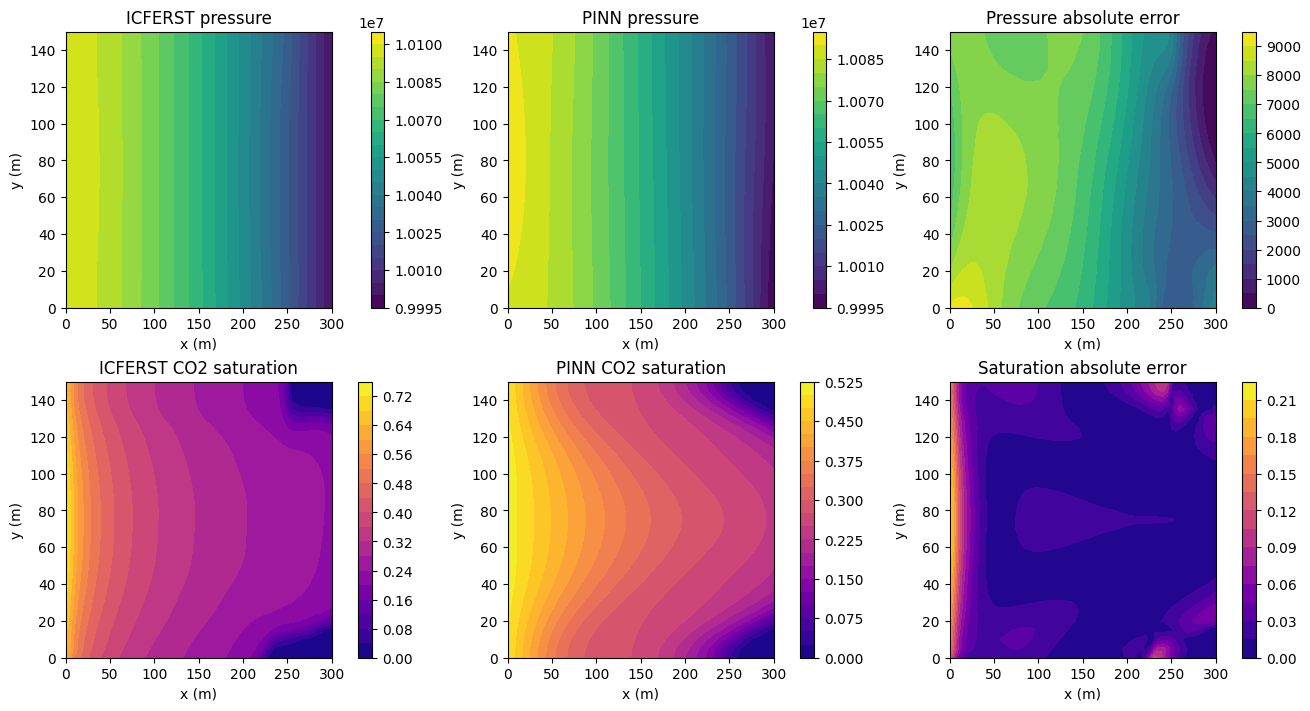

In [10]:
heldout_rows=DATA["heldout_rows"]
chosen=np.unique(heldout_ids)[-1]; local=heldout_ids==chosen; rows=heldout_rows[local]
x,y,truth=unique_xy_field(rows,s_true[local]); _,_,prediction=unique_xy_field(rows,s_pred[local])
_,_,pressure_truth=unique_xy_field(rows,p_true[local]); _,_,pressure_prediction=unique_xy_field(rows,p_pred[local])
fig,axes=plt.subplots(2,3,figsize=(13,7),constrained_layout=True)
fields=[pressure_truth,pressure_prediction,np.abs(pressure_prediction-pressure_truth),
        truth,prediction,np.abs(prediction-truth)]
titles=["ICFERST pressure","PINN pressure","Pressure absolute error",
        "ICFERST CO2 saturation","PINN CO2 saturation","Saturation absolute error"]
for axis,values,title in zip(axes.ravel(),fields,titles):
    artist=axis.tricontourf(x,y,values,levels=20,cmap="viridis" if "pressure" in title.lower() else "plasma")
    axis.set(xlabel="x (m)",ylabel="y (m)",title=title); fig.colorbar(artist,ax=axis)
plt.show()

## 11. Front and mass-conservation diagnostics

A front is the linearly interpolated $S_{CO2}=0.4$ crossing on each horizontal scanline.
Front position complements pixel-wise error. Domain-average saturation is compared across
held-out times as an inventory diagnostic; it does not replace local validation.

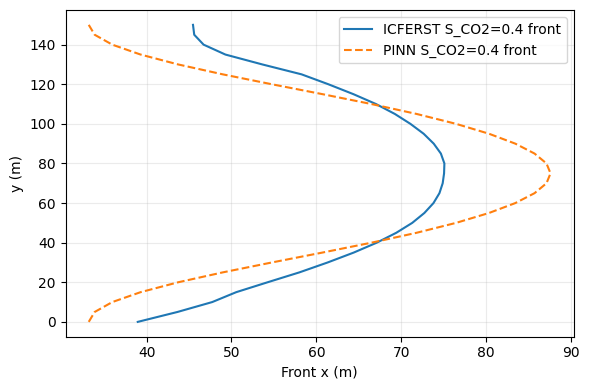

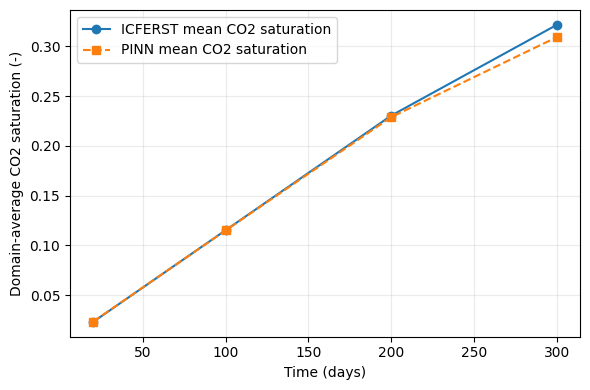

In [11]:
true_fx,true_fy=front_positions(x,y,truth); pred_fx,pred_fy=front_positions(x,y,prediction)
plt.figure(figsize=(6,4)); plt.plot(true_fx,true_fy,label="ICFERST S_CO2=0.4 front")
plt.plot(pred_fx,pred_fy,"--",label="PINN S_CO2=0.4 front")
plt.xlabel("Front x (m)"); plt.ylabel("y (m)"); plt.legend(); plt.grid(alpha=.25); plt.tight_layout(); plt.show()
times=[item["time_days"] for item in heldout_metrics]
truth_inventory=[]; prediction_inventory=[]
for sid in np.unique(heldout_ids):
    local=heldout_ids==sid
    truth_inventory.append(float(s_true[local].mean()))
    prediction_inventory.append(float(s_pred[local].mean()))
plt.figure(figsize=(6,4)); plt.plot(times,truth_inventory,"o-",label="ICFERST mean CO2 saturation")
plt.plot(times,prediction_inventory,"s--",label="PINN mean CO2 saturation")
plt.xlabel("Time (days)"); plt.ylabel("Domain-average CO2 saturation (-)")
plt.legend(); plt.grid(alpha=.25); plt.tight_layout(); plt.show()

## 12. Limitations and exercises

This is not a calibrated storage-site model. It omits gravity segregation, capillary
pressure, CO2 dissolution into brine, compressibility, geochemical reactions, wells,
heterogeneity, and uncertain constitutive laws. The ICFERST mesh is intentionally modest.

**Optional extension reading:** Liaqat, Preston & Schaefer (2025),
[*Predicting the interfacial tension of CO2 and NaCl aqueous solution with machine
learning*](https://doi.org/10.1038/s41598-025-10274-w). Their pressure-temperature-salinity
regression problem can supply an IFT closure in a future capillary-pressure extension; it
is not silently mixed into the present zero-capillarity benchmark.

**Exercises:** (1) perturb the Corey exponents; (2) compare complete-time and random-row
validation; (3) add gravity and predict how the plume changes; (4) design a capillary-pressure
extension; (5) identify which observations most improve front location; (6) explain why an
excellent data fit can coexist with poor phase-balance residuals.